# Analiza rezultatov


V tem delavnem zvezku je prikazana analiza rezultatov sMC imulacij. V ospreduju bo:
- Pristranskost odločanja
- Analiza energije sistema
- porazdelitev delcev

## Datoetke

In [18]:
import pandas as pd

T1 = "0_001"
T2 = "0_100"
T3 = "0_500"
T4 = "1_000"
T5 = "5_000"

TT = [T2,T3,T4,T5]#T1,

energija_file   = [f"energije_{t}.dat" for t in TT]
init_lege_file  = [f"pos_init_{t}.dat" for t in TT]
final_lege_file = [f"pos_final_{t}.dat" for t in TT]
gr_file         = [f"gr_{t}.txt" for t in TT]

df_energija = pd.DataFrame({"Iteracija":[], "Energija":[],"bias":[], "delta":[], "EIN":[], "T":[]})
for i in range(len(TT)):
    df_energija_i = pd.read_csv(energija_file[i], sep="\t",header=None, names=["Iteracija", "Energija", "bias", "delta", "EIN"])
    df_energija_i["T"] = float(TT[i].replace("_", "."))
    df_energija = pd.concat([df_energija, df_energija_i], ignore_index=True)

df_energija.head()

,Iteracija,Energija,bias,delta,EIN,T
0,1.0,-49.130002,0.0,1.812962,0.0,0.1
1,2.0,-49.130002,0.0,1.800271,0.0,0.1
2,3.0,-49.130002,0.0,1.787669,0.0,0.1
3,4.0,-49.130002,0.0,1.775155,0.0,0.1
4,5.0,-49.205972,0.2,1.762729,0.0,0.1


## Pristranskost odločanja

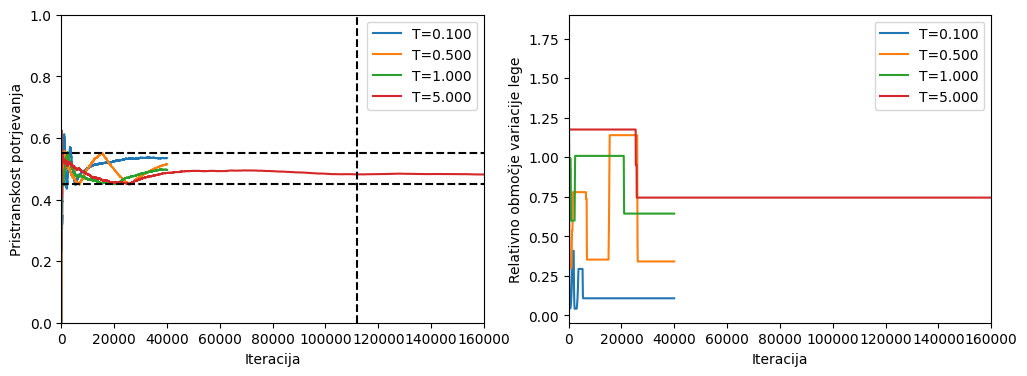

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for T in df_energija["T"].unique():
    df_T = df_energija[df_energija["T"] == T]
    plt.plot(df_T["Iteracija"], df_T["bias"], label=f"T={T:.3f}")
plt.xlabel("Iteracija")
plt.ylabel("Pristranskost potrjevanja")
plt.xlim(0,max(df_T["Iteracija"]))
plt.ylim(0,1)
plt.axhline(y=0.45, color='black', linestyle='--')
plt.axhline(y=0.55, color='black', linestyle='--')
plt.axvline(x = 0.7*max(df_T["Iteracija"]), color='black', linestyle='--')
plt.legend()

plt.subplot(1, 2, 2)
for T in df_energija["T"].unique():
    df_T = df_energija[df_energija["T"] == T]
    plt.plot(df_T["Iteracija"], df_T["delta"], label=f"T={T:.3f}")
plt.xlabel("Iteracija")
plt.ylabel("Relativno območje variacije lege")
plt.xlim(0,max(df_T["Iteracija"]))
plt.legend()
plt.show()

## Energija sistema

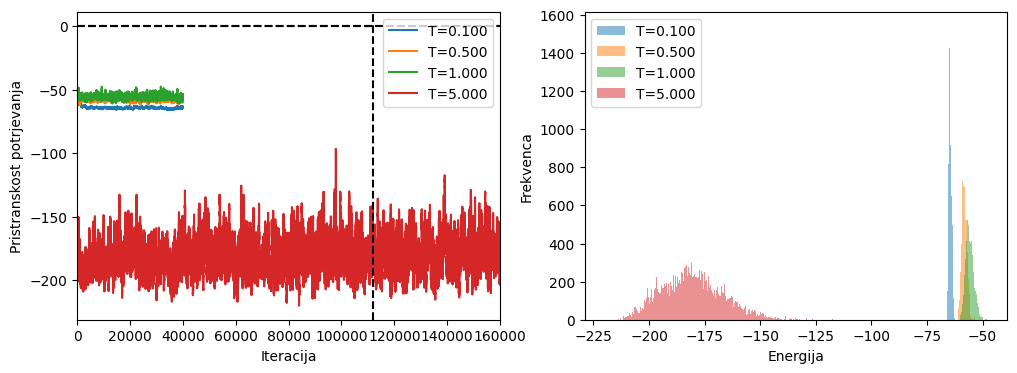

In [20]:
import matplotlib.pyplot as plt
import numpy as np

var = "Energija"

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for T in df_energija["T"].unique():
    df_T = df_energija[df_energija["T"] == T]
    plt.plot(df_T["Iteracija"], df_T[var], label=f"T={T:.3f}")

plt.xlabel("Iteracija")
plt.ylabel("Pristranskost potrjevanja")
plt.xlim(0,max(df_T["Iteracija"]))

plt.axhline(y=0.45, color='black', linestyle='--')
plt.axhline(y=0.55, color='black', linestyle='--')
plt.axvline(x = 0.7*max(df_T["Iteracija"]), color='black', linestyle='--')
plt.legend()

E_min = min(df_energija[var])
E_max = max(df_energija[var])
dE = (E_max - E_min)/1000
n_bins = int((E_max - E_min)/dE)

plt.subplot(1, 2, 2)
for T in df_energija["T"].unique():
    df_T = df_energija[(df_energija["T"] == T) & (df_energija["EIN"]==1)]
    hist = np.zeros(n_bins)
    hist, bins = np.histogram(df_T[var], bins=n_bins, range=(E_min, E_max))
    plt.hist(bins[:-1], bins, weights=hist, label=f"T={T:.3f}", alpha=0.5)
plt.xlabel("Energija")
plt.ylabel("Frekvenca")
plt.legend()
plt.show()

## Radialna porazdelitev delcev

Branje datoteke: gr_0_100.txt
Branje datoteke: gr_0_500.txt
Branje datoteke: gr_1_000.txt
Branje datoteke: gr_5_000.txt
0.1
0.5
1.0
5.0


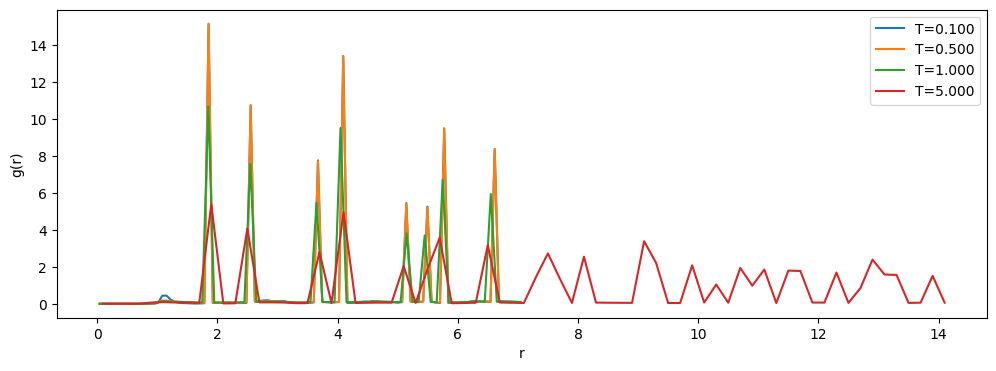

In [21]:
df_gr = pd.DataFrame({"r":[], "g(r)":[], "T":[]})
for i in range(len(gr_file)):
    
    print(f"Branje datoteke: {gr_file[i]}")
    df_gr_i = pd.read_csv(gr_file[i], sep="\t",header=None, names=["r", "g(r)"])
    df_gr_i["T"] = float(TT[i].replace("_", "."))
    df_gr = pd.concat([df_gr, df_gr_i], ignore_index=True)

plt.figure(figsize=(12, 4))
for T in df_gr["T"].unique():
    print(T)
    df_T = df_gr[df_gr["T"] == T]
    plt.plot(df_T["r"], df_T["g(r)"], label=f"T={T:.3f}")
plt.xlabel("r")
plt.ylabel("g(r)")
plt.legend()
plt.show()

## Postavitev delcev

Branje datoteke: pos_init_0_100.dat
Branje datoteke: pos_final_0_100.dat


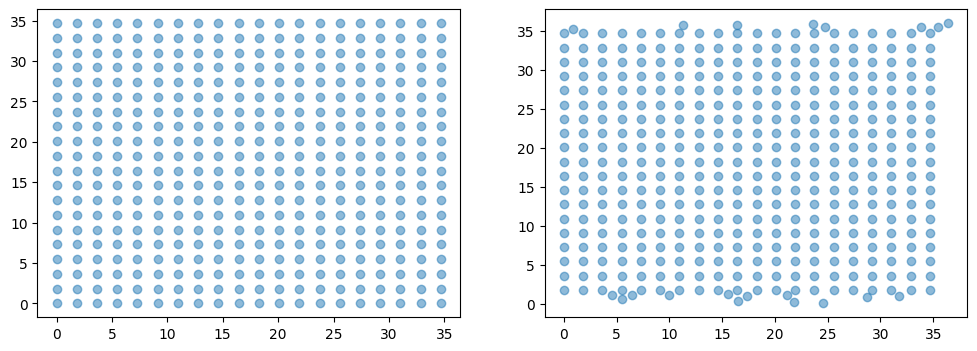

Branje datoteke: pos_init_0_500.dat
Branje datoteke: pos_final_0_500.dat


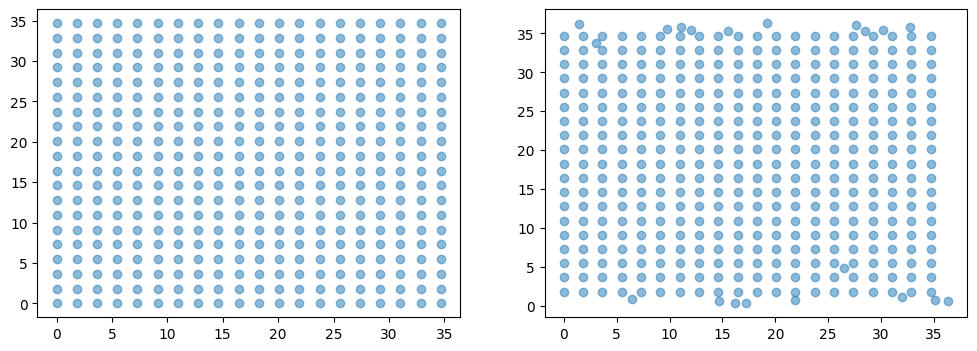

Branje datoteke: pos_init_1_000.dat
Branje datoteke: pos_final_1_000.dat


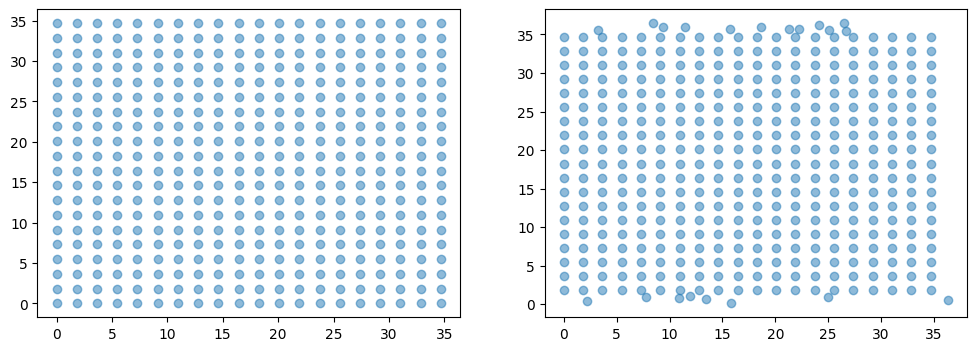

Branje datoteke: pos_init_5_000.dat
Branje datoteke: pos_final_5_000.dat


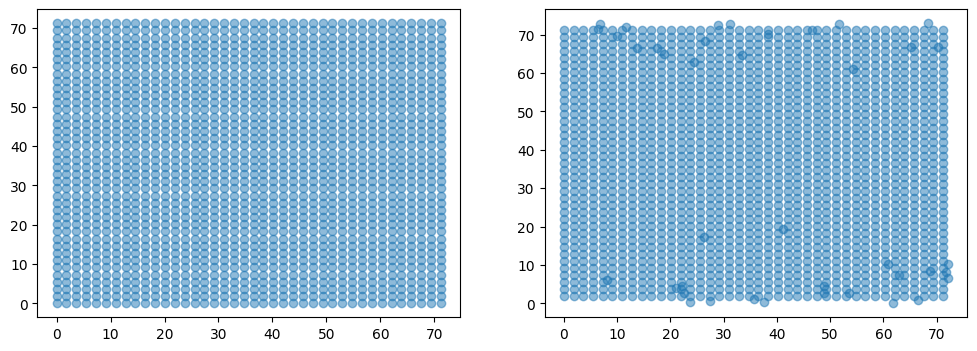

In [23]:
for i in range(len(TT)):
    print(f"Branje datoteke: {init_lege_file[i]}")
    df_init_lege_i = pd.read_csv(init_lege_file[i], sep="\t",header=None, names=["x", "y"])
    print(f"Branje datoteke: {final_lege_file[i]}")
    df_final_lege_i = pd.read_csv(final_lege_file[i], sep="\t",header=None, names=["x", "y"])
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(df_init_lege_i["x"], df_init_lege_i["y"], label="Začetna lega", alpha=0.5)
    plt.subplot(1, 2, 2)
    plt.scatter(df_final_lege_i["x"], df_final_lege_i["y"], label="Končna lega", alpha=0.5)
    plt.show()
    